<a href="https://colab.research.google.com/github/neerabhi/Computer_vision/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [ ]:
data1 = "/content/InnerRaceFault_vload_1.mat"

In [ ]:
data = loadmat(data1)

In [ ]:
print("Top-level keys:", [k for k in data.keys() if not k.startswith('__')])

Top-level keys: ['bearing', 'FTF', 'BPFO', 'BPFI', 'BSF']


In [ ]:
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Thu Jan 17 13:09:15 2013',
 '__version__': '1.0',
 '__globals__': [],
 'bearing': array([[(array([[25]], dtype=uint8), array(['0'], dtype='<U1'), array([[-0.1762558],
                [-0.5284473],
                [ 0.1484201],
                ...,
                [-0.360338 ],
                [-1.036233 ],
                [-0.3933298]]), array([[48828]], dtype=uint16))                      ]],
       dtype=[('rate', 'O'), ('load', 'O'), ('gs', 'O'), ('sr', 'O')]),
 'FTF': array([[14.8375]]),
 'BPFO': array([[81.125]]),
 'BPFI': array([[118.875]]),
 'BSF': array([[63.91]])}

In [ ]:
for k in ('BPFO','BPFI','BSF','FTF'):
    if k in data:
        print(f"{k} = {np.squeeze(data[k])}")

BPFO = 81.125
BPFI = 118.875
BSF = 63.91
FTF = 14.8375


In [ ]:
BPFO = 81.125
BPFI = 118.875
BSF = 63.91
FTF = 14.8375

In [ ]:
bearing_raw = data['bearing']
print("raw bearing object type/shape:", type(bearing_raw), np.shape(bearing_raw))

raw bearing object type/shape: <class 'numpy.ndarray'> (1, 1)


In [ ]:
b = bearing_raw[0,0]
print("bearing dtype.names (fields):", b.dtype.names)

bearing dtype.names (fields): ('rate', 'load', 'gs', 'sr')


In [ ]:
gs = np.squeeze(b['gs'])      # acceleration signal (should be 14684 x 1)
sr = float(np.squeeze(b['sr']))   # sampling rate (Hz)
rate = np.squeeze(b['rate'])      # shaft rate (Hz) or rpm depending on dataset
load = np.squeeze(b['load'])

In [ ]:
print("gs.shape:", gs.shape)
print("sr (sampling rate):", sr)
print("rate:", rate)
print("load:", load)

gs.shape: (146484,)
sr (sampling rate): 48828.0
rate: 25
load: 0


In [ ]:
N = gs.size
duration_s = N / sr
print("Signal Length: ",N)
print("Signal Duration: ",duration_s)

Signal Length:  146484
Signal Duration:  3.0


In [ ]:
t = np.arange(N) / sr
# tmax = min(2.0, t[-1])
# idx_max = int(tmax * sr)

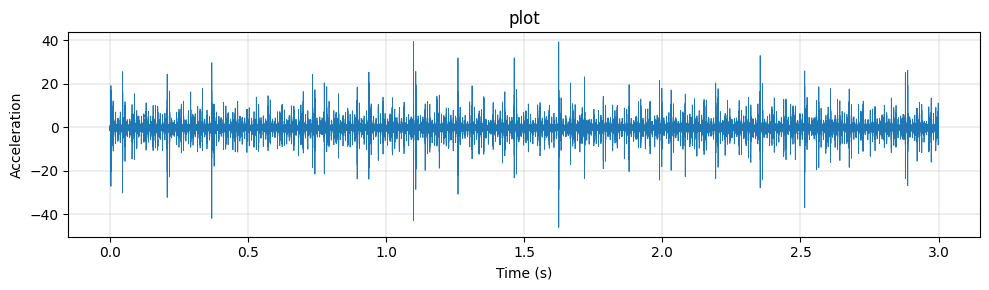

In [ ]:
plt.figure(figsize=(10,3))
plt.plot(t[:], gs[:], linewidth=0.6)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.title("plot")
plt.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()

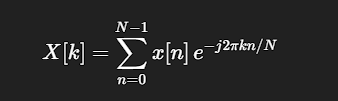

In [ ]:
# def dft(x):
#     x = np.asarray(x, dtype=complex)
#     N = x.shape[0]
#     n = np.arange(N)
#     k = n.reshape((N, 1))
#     M = np.exp(-2j * np.pi * k * n / N)
#     return np.dot(M, x)

def dft(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)

    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-2j * np.pi * k * n / N)

    return X

In [ ]:
N = len(gs)
if N > 4096:
    x = gs[:4096]
else:
    x = gs
X = dft(x)
freqs = np.arange(len(X)) * sr / len(X)

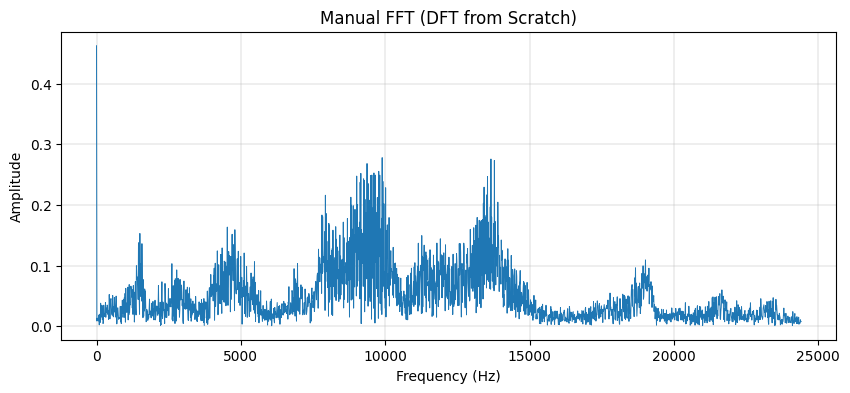

In [ ]:
half = len(X)//2
X_mag = np.abs(X[:half]) * 2 / len(X)

# Plot
plt.figure(figsize=(10,4))
plt.plot(freqs[:half], X_mag, linewidth=0.7)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Manual FFT (DFT from Scratch)")
plt.grid(True, linewidth=0.3)

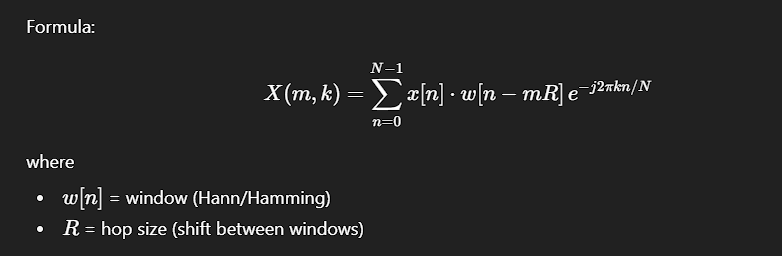

In [ ]:
def stft_manual(x, sr, window_size=512, hop_size=256):
    w = np.hamming(window_size)
    frames = []
    for start in range(0, len(x)-window_size, hop_size):
        frame = x[start:start+window_size] * w
        X = dft(frame)
        frames.append(np.abs(X[:window_size//2]))
    return np.array(frames).T

In [ ]:
spec = stft_manual(gs[:4096], sr, window_size=256, hop_size=128)

In [ ]:
spec.shape

(128, 30)

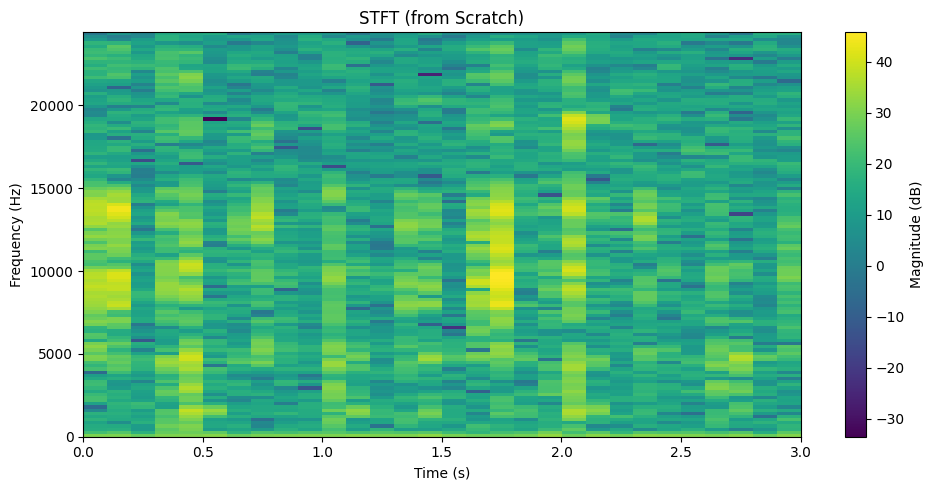

In [ ]:
plt.figure(figsize=(10,5))
plt.imshow(20*np.log10(spec + 1e-6), origin='lower', aspect='auto',
           extent=[0, len(gs[:1000000])/sr, 0, sr/2])
plt.colorbar(label="Magnitude (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("STFT (from Scratch)")
plt.tight_layout()
plt.show()

In [ ]:
# fs = sr                  # sampling rate
# lowcut = 4500            # lower cutoff frequency (Hz)
# highcut = 7500            # upper cutoff frequency (Hz)
# filter_length = 101      # number of filter coefficients (odd -> symmetric)

In [ ]:
fs=sr

In [ ]:
center_freq = 12000    # The resonance frequency we identified.
bandwidth = 4000       # The width of the resonance band.
filter_length = 151

In [ ]:
lowcut = center_freq - (bandwidth / 2)
highcut = center_freq + (bandwidth / 2)

In [ ]:
print(f"Designing filter for the bearing signal...")
print(f" -> Center Frequency: {center_freq} Hz")
print(f" -> Bandwidth: {bandwidth} Hz")
print(f" -> Cutoff Frequencies: {int(lowcut)} Hz to {int(highcut)} Hz")

Designing filter for the bearing signal...
 -> Center Frequency: 12000 Hz
 -> Bandwidth: 4000 Hz
 -> Cutoff Frequencies: 10000 Hz to 14000 Hz


In [ ]:
def fir_bandpass_corrected(lowcut, highcut, fs, N):
    """Creates a corrected FIR bandpass filter using the windowed-sinc method."""
    fc1 = lowcut / fs
    fc2 = highcut / fs
    M = N - 1
    n = np.arange(N)
    h1 = 2 * fc2 * np.sinc(2 * fc2 * (n - M/2))
    h2 = 2 * fc1 * np.sinc(2 * fc1 * (n - M/2))
    h_ideal = h1 - h2
    w = np.hamming(N)
    h = h_ideal * w
    return h

In [ ]:
h = fir_bandpass_corrected(lowcut, highcut, fs, filter_length)

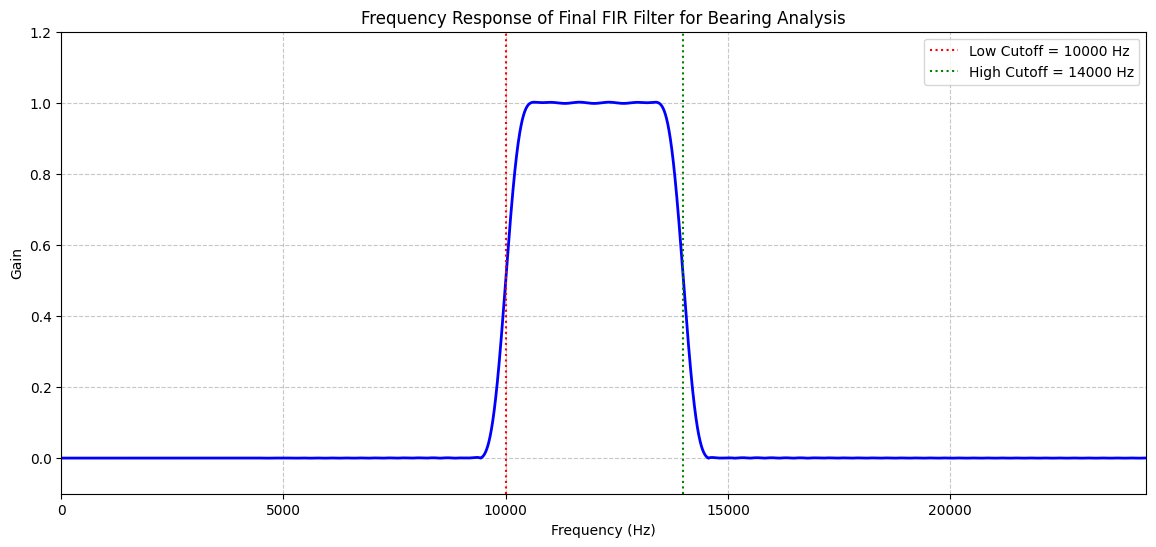

In [ ]:
from scipy.signal import freqz, filtfilt

w_rad, h_response = freqz(h, worN=8000)
frequencies_hz = (w_rad / np.pi) * (fs / 2)

plt.figure(figsize=(14, 6))
plt.plot(frequencies_hz, np.abs(h_response), 'b', linewidth=2)
plt.title('Frequency Response of Final FIR Filter for Bearing Analysis')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.axvline(lowcut, color='red', linestyle=':', label=f'Low Cutoff = {int(lowcut)} Hz')
plt.axvline(highcut, color='green', linestyle=':', label=f'High Cutoff = {int(highcut)} Hz')
plt.ylim(-0.1, 1.2)
plt.xlim(0, fs/2)
plt.legend()
plt.show()

In [ ]:
def manual_convolve(x, h):
    Nx = len(x)
    Nh = len(h)
    y = np.zeros(Nx + Nh - 1)
    for n in range(len(y)):
        for k in range(Nh):
            if 0 <= n-k < Nx:
                y[n] += h[k] * x[n-k]
    return y

In [ ]:
def idft(X):
    N = len(X)
    x = np.zeros(N, dtype=complex)

    for n in range(N):
        for k in range(N):
            x[n] += X[k] * np.exp(2j * np.pi * k * n / N)

    return x / N

In [ ]:
filtered_signal = manual_convolve(gs, h)

In [ ]:
N = len(filtered_signal)
signal_fft = np.fft.fft(filtered_signal)
H = np.zeros(N)
if N % 2 == 0:
    # For even length N
    H[0] = H[N // 2] = 1
    H[1:N // 2] = 2
else:
    # For odd length N
    H[0] = 1
    H[1:(N + 1) // 2] = 2

analytic_signal_fft = signal_fft * H
analytic_signal = np.fft.ifft(analytic_signal_fft)


In [ ]:
envelope = np.abs(analytic_signal)
N_env = len(envelope)
envelope_fft = np.fft.fft(envelope)
amplitude_spectrum = np.abs(envelope_fft) / N_env
amplitude_spectrum_one_sided = amplitude_spectrum[:N_env // 2 + 1]
amplitude_spectrum_one_sided[1:] *= 2
freq_axis = np.fft.rfftfreq(N_env, d=1/sr)


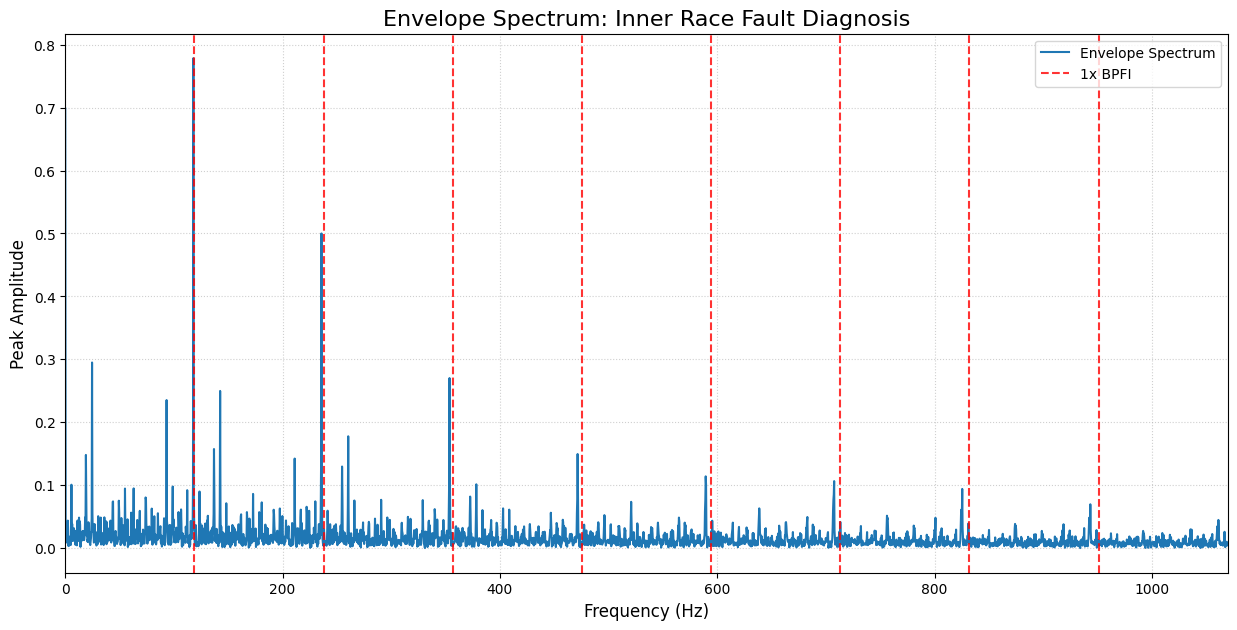

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(freq_axis, amplitude_spectrum_one_sided, label='Envelope Spectrum')

# Plot vertical lines for BPFI harmonics
max_harmonics = 8
for i in range(1, max_harmonics + 1):
    harmonic_freq = BPFI * i
    plt.axvline(x=harmonic_freq, color='r', linestyle='--', alpha=0.8,
                label=f'{i}x BPFI' if i == 1 else None) # Only label the first line

plt.title('Envelope Spectrum: Inner Race Fault Diagnosis', fontsize=16)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Peak Amplitude', fontsize=12)
plt.xlim(0, BPFI * (max_harmonics + 1)) # Limit x-axis to show relevant harmonics
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend()
plt.show()

Part 2

Successfully loaded data from: /content/normal_baseline_1.mat
gs_normal.shape: (585936,)
sr_normal (sampling rate): 97656.0 Hz
BPFI for comparison: 118.875 Hz
BPFO for comparison: 81.125 Hz


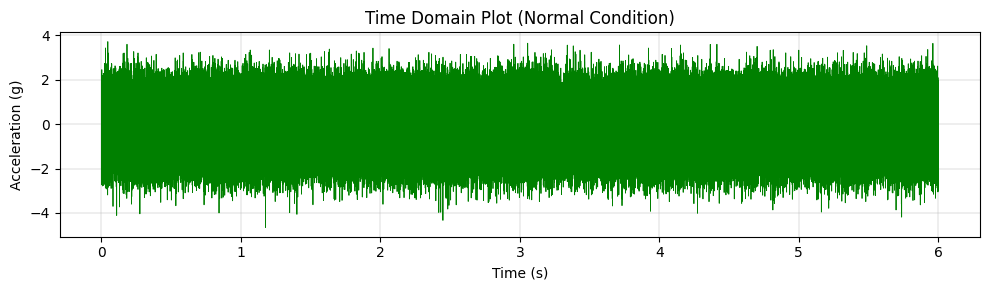

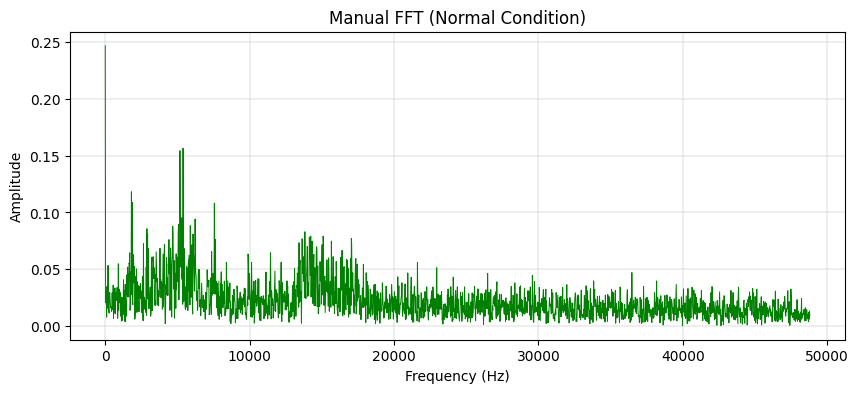

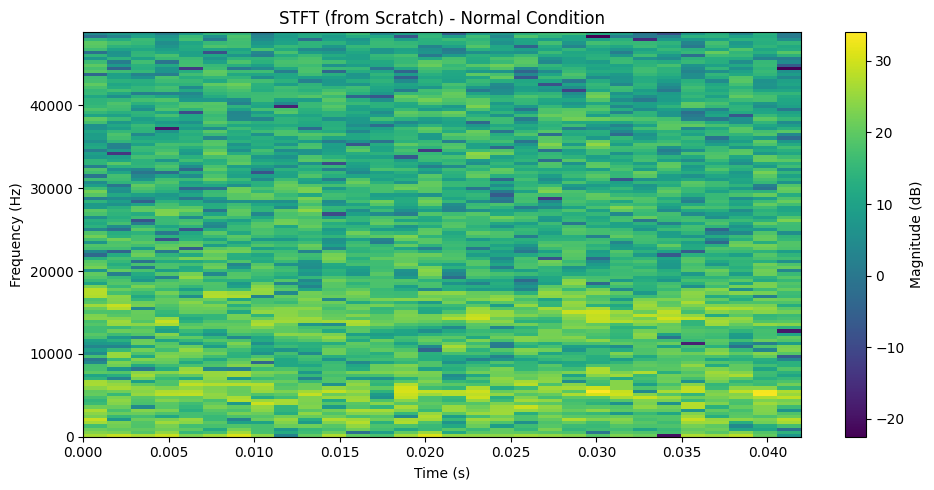


Filter applied to the normal condition signal.
Envelope of the normal signal computed.


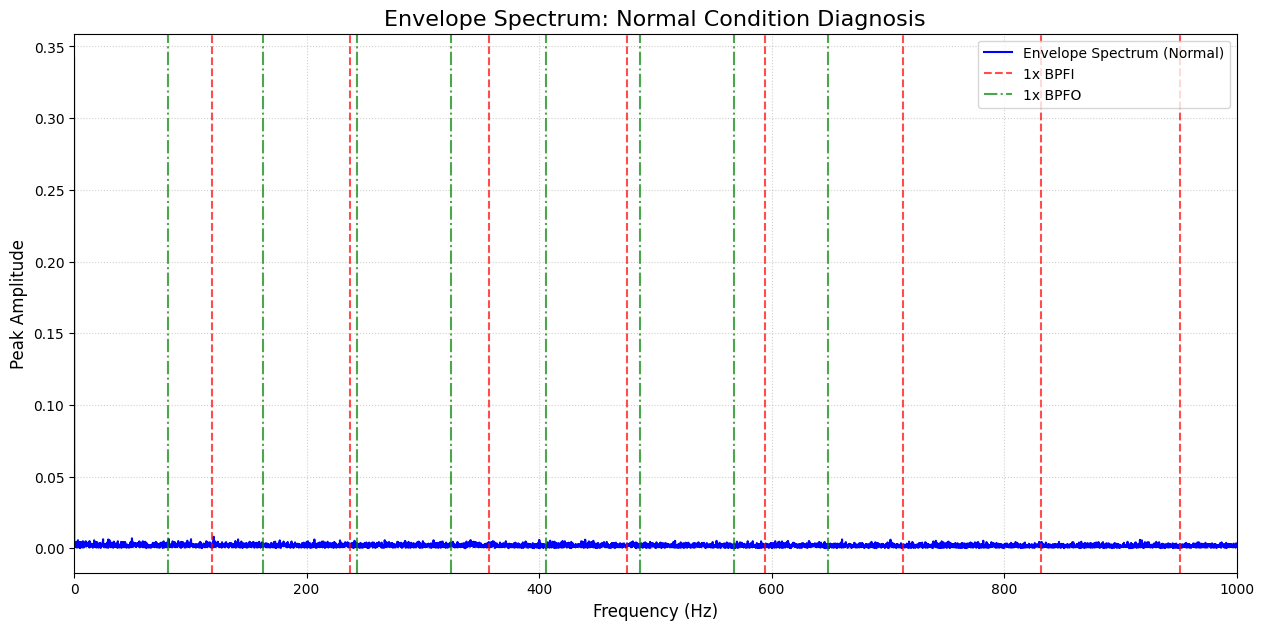

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
data2_path = "/content/normal_baseline_1.mat"

# Load the .mat file
try:
    data_normal = loadmat(data2_path)
    print(f"Successfully loaded data from: {data2_path}")

    if 'bearing' in data_normal:
        b_normal = data_normal['bearing'][0,0]
        gs_normal = np.squeeze(b_normal['gs'])
        sr_normal = float(np.squeeze(b_normal['sr']))
    else: # If the structure is flatter
        gs_normal = data_normal['gs'].flatten()
        sr_normal = data_normal['sr'].flatten()[0]

    # Load fault frequencies for comparison, if they exist in the file
    BPFO_normal = np.squeeze(data_normal.get('BPFO', 0))
    BPFI_normal = np.squeeze(data_normal.get('BPFI', 0))

    print(f"gs_normal.shape: {gs_normal.shape}")
    print(f"sr_normal (sampling rate): {sr_normal} Hz")
    print(f"BPFI for comparison: {BPFI_normal} Hz")
    print(f"BPFO for comparison: {BPFO_normal} Hz")

except FileNotFoundError:
    print(f"Error: The file was not found at {data2_path}. Please check the path.")
    gs_normal = None


# ===================================================================
# Step 2: Plot in Time & Frequency Domain (Assuming gs_normal loaded)
# ===================================================================
if gs_normal is not None:
    # --- Time Domain Plot ---
    N_normal = gs_normal.size
    t_normal = np.arange(N_normal) / sr_normal

    plt.figure(figsize=(10,3))
    plt.plot(t_normal, gs_normal, linewidth=0.6, color='green')
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (g)")
    plt.title("Time Domain Plot (Normal Condition)")
    plt.grid(True, linewidth=0.3)
    plt.tight_layout()
    plt.show()

    # --- Manual FFT (DFT) Plot ---
    # Use a subset of data for the manual DFT to avoid long computation times
    x_normal = gs_normal[:4096]
    X_normal = dft(x_normal)
    freqs_normal = np.arange(len(X_normal)) * sr_normal / len(X_normal)

    half_normal = len(X_normal)//2
    X_mag_normal = np.abs(X_normal[:half_normal]) * 2 / len(X_normal)

    plt.figure(figsize=(10,4))
    plt.plot(freqs_normal[:half_normal], X_mag_normal, linewidth=0.7, color='green')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.title("Manual FFT (Normal Condition)")
    plt.grid(True, linewidth=0.3)
    plt.show()

# ===================================================================
# Step 3: Perform STFT (from Scratch)
# ===================================================================
if gs_normal is not None:
    spec_normal = stft_manual(gs_normal[:4096], sr_normal, window_size=256, hop_size=128)

    plt.figure(figsize=(10,5))
    plt.imshow(20*np.log10(spec_normal + 1e-6), origin='lower', aspect='auto',
               extent=[0, len(gs_normal[:4096])/sr_normal, 0, sr_normal/2])
    plt.colorbar(label="Magnitude (dB)")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title("STFT (from Scratch) - Normal Condition")
    plt.tight_layout()
    plt.show()

# ===================================================================
# Step 4: Design and Apply Bandpass FIR Filter
# ===================================================================
if gs_normal is not None:

    fs_normal = sr_normal
    center_freq = 12000
    bandwidth = 4000
    filter_length = 151
    lowcut = center_freq - (bandwidth / 2)
    highcut = center_freq + (bandwidth / 2)

    # Design the filter using your custom function
    h_normal = fir_bandpass_corrected(lowcut, highcut, fs_normal, filter_length)

    # Apply the filter using your manual convolution function
    filtered_signal_normal = manual_convolve(gs_normal, h_normal)

    print("\nFilter applied to the normal condition signal.")

# Step 5: Compute the Envelope Using Hilbert Transform (from Scratch)
# ===================================================================
if gs_normal is not None:
    N_filt_normal = len(filtered_signal_normal)
    signal_fft_normal = np.fft.fft(filtered_signal_normal)

    H_normal = np.zeros(N_filt_normal)
    if N_filt_normal % 2 == 0:
        H_normal[0] = H_normal[N_filt_normal // 2] = 1
        H_normal[1:N_filt_normal // 2] = 2
    else:
        H_normal[0] = 1
        H_normal[1:(N_filt_normal + 1) // 2] = 2

    analytic_signal_fft_normal = signal_fft_normal * H_normal
    analytic_signal_normal = np.fft.ifft(analytic_signal_fft_normal)

    envelope_normal = np.abs(analytic_signal_normal)
    print("Envelope of the normal signal computed.")

# ===================================================================
# Step 6 & 7: Compute & Plot the One-sided Power/Amplitude Spectrum
# ===================================================================
if gs_normal is not None:
    N_env_normal = len(envelope_normal)
    envelope_fft_normal = np.fft.fft(envelope_normal)

    # Calculate one-sided amplitude spectrum
    amplitude_spectrum_normal = np.abs(envelope_fft_normal) / N_env_normal
    amplitude_spectrum_one_sided_normal = amplitude_spectrum_normal[:N_env_normal // 2 + 1]
    amplitude_spectrum_one_sided_normal[1:] *= 2
    freq_axis_normal = np.fft.rfftfreq(N_env_normal, d=1/sr_normal)

    # --- Final Plot ---
    plt.figure(figsize=(15, 7))
    plt.plot(freq_axis_normal, amplitude_spectrum_one_sided_normal, label='Envelope Spectrum (Normal)', color='blue')

    # Plot vertical lines for BPFI and BPFO harmonics for comparison
    max_harmonics = 8
    for i in range(1, max_harmonics + 1):
        # Plot BPFI lines (if value is available)
        if BPFI_normal > 0:
            plt.axvline(x=BPFI_normal * i, color='r', linestyle='--', alpha=0.7,
                        label=f'{i}x BPFI' if i == 1 else None)
        # Plot BPFO lines (if value is available)
        if BPFO_normal > 0:
            plt.axvline(x=BPFO_normal * i, color='g', linestyle='-.', alpha=0.7,
                        label=f'{i}x BPFO' if i == 1 else None)

    plt.title('Envelope Spectrum: Normal Condition Diagnosis', fontsize=16)
    plt.xlabel('Frequency (Hz)', fontsize=12)
    plt.ylabel('Peak Amplitude', fontsize=12)
    plt.xlim(0, 1000) # Set a reasonable limit to see potential fault frequencies
    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

Part 3

Successfully loaded data from: /content/OuterRaceFault_vload_1.mat
gs_outer.shape: (146484,)
sr_outer (sampling rate): 48828.0 Hz
BPFO (Fault Frequency): 81.125 Hz

--- Performing Initial Analysis with General Filter ---


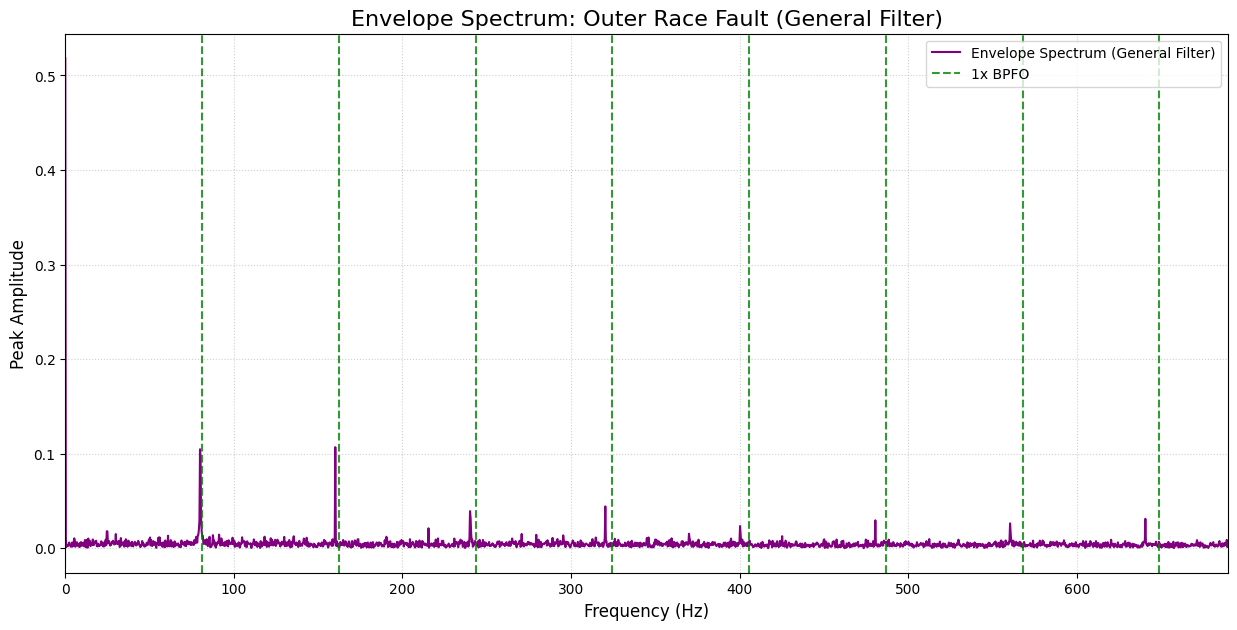


--- Computing Kurtosis Values ---
Could not compute all kurtosis values. Ensure 'gs_normal' and 'gs_inner' are loaded from Parts 1 & 2.

--- Re-analyzing with Specific Filter (fc=2670, BW=763) ---


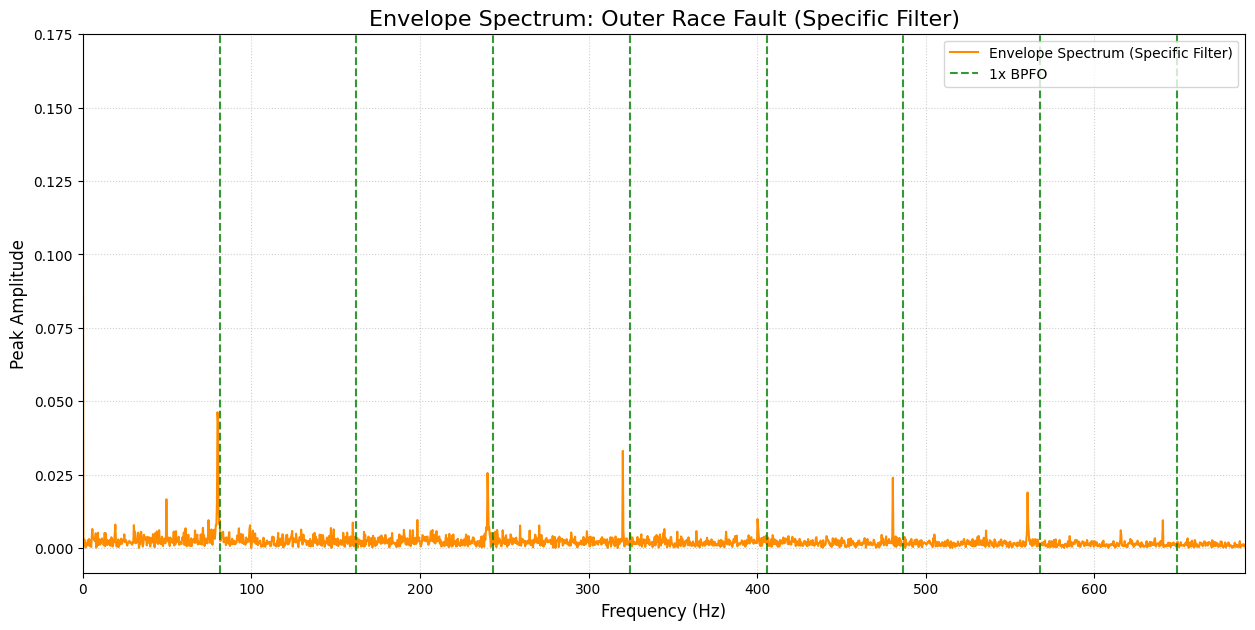

In [ ]:
# Import additional libraries needed for this part
from scipy.stats import kurtosis

data3_path = "/content/OuterRaceFault_vload_1.mat"

try:
    data_outer = loadmat(data3_path)
    print(f"Successfully loaded data from: {data3_path}")

    # Extract data using the same structure as before
    if 'bearing' in data_outer:
        b_outer = data_outer['bearing'][0,0]
        gs_outer = np.squeeze(b_outer['gs'])
        sr_outer = float(np.squeeze(b_outer['sr']))
    else:
        gs_outer = data_outer['gs'].flatten()
        sr_outer = data_outer['sr'].flatten()[0]

    # Load the specific fault frequency for the outer race
    BPFO = np.squeeze(data_outer.get('BPFO', 0))

    print(f"gs_outer.shape: {gs_outer.shape}")
    print(f"sr_outer (sampling rate): {sr_outer} Hz")
    print(f"BPFO (Fault Frequency): {BPFO} Hz")

except FileNotFoundError:
    print(f"Error: The file was not found at {data3_path}. Please check the path.")
    gs_outer = None

# ===================================================================
# Analysis 1: Repeating steps with a general high-frequency filter
# ===================================================================
if gs_outer is not None:
    print("\n--- Performing Initial Analysis with General Filter ---")

    # Use the same general filter design as Part 1 for a consistent first look
    fs_outer = sr_outer
    filter_length_gen = 151
    center_freq_gen = 12000
    bandwidth_gen = 4000
    lowcut_gen = center_freq_gen - (bandwidth_gen / 2)
    highcut_gen = center_freq_gen + (bandwidth_gen / 2)

    # 1. Design the filter
    h_outer_gen = fir_bandpass_corrected(lowcut_gen, highcut_gen, fs_outer, filter_length_gen)

    # 2. Apply the filter via manual convolution
    filtered_signal_gen = manual_convolve(gs_outer, h_outer_gen)

    # 3. Compute the envelope using the manual Hilbert method
    N_filt_gen = len(filtered_signal_gen)
    signal_fft_gen = np.fft.fft(filtered_signal_gen)
    H_gen = np.zeros(N_filt_gen)
    if N_filt_gen % 2 == 0:
        H_gen[0] = H_gen[N_filt_gen // 2] = 1
        H_gen[1:N_filt_gen // 2] = 2
    else:
        H_gen[0] = 1
        H_gen[1:(N_filt_gen + 1) // 2] = 2
    analytic_signal_gen = np.fft.ifft(signal_fft_gen * H_gen)
    envelope_gen = np.abs(analytic_signal_gen)

    # 4. Compute and Plot the One-sided Amplitude Spectrum
    N_env_gen = len(envelope_gen)
    envelope_fft_gen = np.fft.fft(envelope_gen)
    amp_spec_gen = np.abs(envelope_fft_gen) / N_env_gen
    amp_spec_one_sided_gen = amp_spec_gen[:N_env_gen // 2 + 1]
    amp_spec_one_sided_gen[1:] *= 2
    freq_axis_gen = np.fft.rfftfreq(N_env_gen, d=1/sr_outer)

    plt.figure(figsize=(15, 7))
    plt.plot(freq_axis_gen, amp_spec_one_sided_gen, label='Envelope Spectrum (General Filter)', color='purple')

    # Plot vertical lines for BPFO harmonics
    max_harmonics = 8
    for i in range(1, max_harmonics + 1):
        harmonic_freq = BPFO * i
        plt.axvline(x=harmonic_freq, color='g', linestyle='--', alpha=0.8,
                    label=f'{i}x BPFO' if i == 1 else None)

    plt.title('Envelope Spectrum: Outer Race Fault (General Filter)', fontsize=16)
    plt.xlabel('Frequency (Hz)', fontsize=12)
    plt.ylabel('Peak Amplitude', fontsize=12)
    plt.xlim(0, BPFO * (max_harmonics + 0.5))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

# ===================================================================
# Step 3: Compute and Compare Kurtosis Values
# ===================================================================
if gs_outer is not None:
    print("\n--- Computing Kurtosis Values ---")
    try:
        # fisher=False gives Pearson's kurtosis (3 for normal distribution)
        kurt_normal = kurtosis(gs_normal, fisher=False)
        kurt_inner = kurtosis(gs_inner, fisher=False)
        kurt_outer = kurtosis(gs_outer, fisher=False)

        print(f"Kurtosis of Normal Signal:      {kurt_normal:.4f}")
        print(f"Kurtosis of Inner Race Fault:   {kurt_inner:.4f}")
        print(f"Kurtosis of Outer Race Fault:   {kurt_outer:.4f}")
    except NameError:
        print("Could not compute all kurtosis values. Ensure 'gs_normal' and 'gs_inner' are loaded from Parts 1 & 2.")

# ===================================================================
# Step 4 & 5: Analysis with the Specified Bandpass Filter
# ===================================================================
if gs_outer is not None:
    print("\n--- Re-analyzing with Specific Filter (fc=2670, BW=763) ---")

    # 1. Design the new, specific filter
    filter_length_spec = 151 # Keeping filter order consistent
    fc_spec = 2670
    bw_spec = 763
    lowcut_spec = fc_spec - (bw_spec / 2)
    highcut_spec = fc_spec + (bw_spec / 2)

    h_outer_spec = fir_bandpass_corrected(lowcut_spec, highcut_spec, fs_outer, filter_length_spec)

    # 2. Apply the new filter
    filtered_signal_spec = manual_convolve(gs_outer, h_outer_spec)

    # 3. Compute the envelope
    N_filt_spec = len(filtered_signal_spec)
    signal_fft_spec = np.fft.fft(filtered_signal_spec)
    H_spec = np.zeros(N_filt_spec)
    if N_filt_spec % 2 == 0:
        H_spec[0] = H_spec[N_filt_spec // 2] = 1
        H_spec[1:N_filt_spec // 2] = 2
    else:
        H_spec[0] = 1
        H_spec[1:(N_filt_spec + 1) // 2] = 2
    analytic_signal_spec = np.fft.ifft(signal_fft_spec * H_spec)
    envelope_spec = np.abs(analytic_signal_spec)

    # 4. Compute and Plot the Final Spectrum
    N_env_spec = len(envelope_spec)
    envelope_fft_spec = np.fft.fft(envelope_spec)
    amp_spec_spec = np.abs(envelope_fft_spec) / N_env_spec
    amp_spec_one_sided_spec = amp_spec_spec[:N_env_spec // 2 + 1]
    amp_spec_one_sided_spec[1:] *= 2
    freq_axis_spec = np.fft.rfftfreq(N_env_spec, d=1/sr_outer)

    plt.figure(figsize=(15, 7))
    plt.plot(freq_axis_spec, amp_spec_one_sided_spec, label='Envelope Spectrum (Specific Filter)', color='darkorange')

    for i in range(1, max_harmonics + 1):
        harmonic_freq = BPFO * i
        plt.axvline(x=harmonic_freq, color='g', linestyle='--', alpha=0.8,
                    label=f'{i}x BPFO' if i == 1 else None)

    plt.title('Envelope Spectrum: Outer Race Fault (Specific Filter)', fontsize=16)
    plt.xlabel('Frequency (Hz)', fontsize=12)
    plt.ylabel('Peak Amplitude', fontsize=12)
    plt.xlim(0, BPFO * (max_harmonics + 0.5))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()